In [19]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import json

import scienceplots

In [ ]:
DARK_BLUE  = (0.0, 0.4667, 0.7333)
LIGHT_BLUE = (0.2, 0.7333, 0.9333)
GREEN      = (0.0, 0.6, 0.5333)
ORANGE     = (0.9333, 0.4667, 0.2)
RED        = (0.8, 0.2, 0.0667)
PINK       = (0.9333, 0.2, 0.4667)
GRAY       = (0.7333, 0.7333, 0.7333)

SAVE = False

## Fig 1

In [21]:
RUNS = {
    "Rest": 
    {
        "folder": '/Users/juliuswuerzler/Documents/Uni/Master/MasterThesis/results/02_04_12_45_209_RST',
        "color": GRAY
    },
    "No feedback": 
    {
        "folder": '/Users/juliuswuerzler/Desktop/2Pong/New/New Pong/02_12_20_51_trial_NT_OLDTP_Var02_300s_30Hz_yEnc_NoFB',
        "color": DARK_BLUE
    },
    "Feedback": 
    {
        "folder": '/Users/juliuswuerzler/Desktop/2Pong/New/New Pong/02_12_18_26_trial_NT_OLDTP_Var02_300s_30Hz_yEnc',
        "color": ORANGE
    }
}


In [22]:
def ema(x, alpha=0.1):
    """Exponential moving average."""
    y = np.zeros_like(x, dtype=float)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha * x[i] + (1 - alpha) * y[i-1]
    return y


def average_rally_length(arr):
    """Calculate mean rally length (sequence between misses/zeros)."""
    arr = np.asarray(arr)
    zero_idx = np.where(arr == 0)[0]
    
    if len(zero_idx) == 0:
        return len(arr)
    
    prev_zero_idx = np.concatenate(([-1], zero_idx[:-1]))
    lengths = zero_idx - prev_zero_idx - 1
    return np.mean(lengths)


def long_rallies(arr):
    """Fraction of rallies with length >= 3."""
    arr = np.asarray(arr)
    zero_idx = np.where(arr == 0)[0]
    
    if len(zero_idx) == 0:
        return float(len(arr) >= 3)
    
    prev_zero = np.concatenate(([-1], zero_idx[:-1]))
    lengths = zero_idx - prev_zero - 1
    return np.mean(lengths >= 3)


def aces(arr):
    """Fraction of rallies with length == 0 (immediate miss)."""
    arr = np.asarray(arr)
    zero_idx = np.where(arr == 0)[0]
    
    if len(zero_idx) == 0:
        return 0.0  # Fixed: return scalar, not array
    
    prev_zero_idx = np.concatenate(([-1], zero_idx[:-1]))
    lengths = zero_idx - prev_zero_idx - 1
    return np.mean(lengths == 0)

In [36]:
# Configuration
ALPHA = 0.05
N = 50

# Define metrics to compute
METRICS = {
    'Aces': {'func': aces, 'scale': 100},
    'RL': {'func': average_rally_length, 'scale': 1},
    'LR': {'func': long_rallies, 'scale': 100}
}

# Process each run
for run in RUNS:
    result_files = glob.glob(os.path.join(RUNS[run]['folder'], "*results.csv"))
    RUNS[run]['results'] = {}
    
    # Initialize collectors
    rolling_means = []
    start_end_collectors = {'start': [], 'end': []}
    metric_collectors = {
        metric: {'start': [], 'end': []} 
        for metric in METRICS
    }
    
    # Process each network file
    for f in result_files:
        network = f.split('_')[-2]
        results = np.loadtxt(f)
        RUNS[run]['results'][network] = {}
        
        # Rolling mean
        smoothed_results = ema(results, ALPHA)
        RUNS[run]['results'][network]['rolling means'] = smoothed_results
        rolling_means.append(smoothed_results)
        
        # Start and end performance
        start_results = np.mean(results[:N])
        end_results = np.mean(results[-N:])
        RUNS[run]['results'][network]['s'] = start_results
        RUNS[run]['results'][network]['e'] = end_results
        start_end_collectors['start'].append(start_results)
        start_end_collectors['end'].append(end_results)
        
        # Compute all metrics
        for metric_name, metric_config in METRICS.items():
            func = metric_config['func']
            scale = metric_config['scale']
            
            RUNS[run]['results'][network][metric_name] = {}
            start_val = func(results[:N]) * scale
            end_val = func(results[-N:]) * scale
            
            RUNS[run]['results'][network][metric_name]['s'] = start_val
            RUNS[run]['results'][network][metric_name]['e'] = end_val
            
            metric_collectors[metric_name]['start'].append(start_val)
            metric_collectors[metric_name]['end'].append(end_val)
    
    # Store aggregated results
    RUNS[run]['rolling means'] = np.array(rolling_means)
    RUNS[run]['start'] = np.array(start_end_collectors['start'])
    RUNS[run]['end'] = np.array(start_end_collectors['end'])
    
    for metric_name in METRICS:
        RUNS[run][metric_name] = {
            'start': np.array(metric_collectors[metric_name]['start']),
            'end': np.array(metric_collectors[metric_name]['end'])
        }

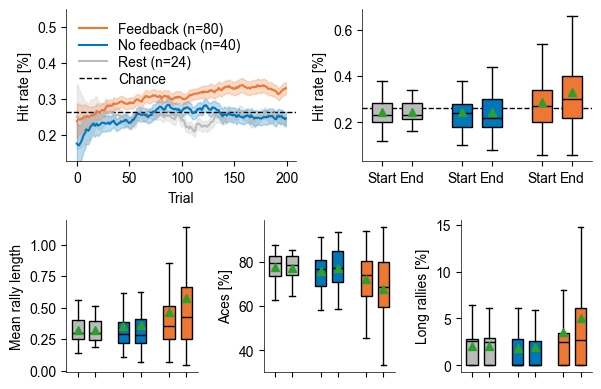

In [37]:
plt.style.use(['nature_d'])
fig, axs = plt.subplot_mosaic(
    [
        ["OT", "OT", "OT", "SvE", "SvE", "SvE"],
        ["RL", "RL", "Aces", "Aces", "LR", "LR"]
    ],
    sharey=False
)

# Plot configuration
BOXPLOT_CONFIG = {
    'widths': 0.5,
    'patch_artist': True,
    'showfliers': False,
    'showmeans': True
}

axs['OT'].axhline(25/95, linestyle='--', color='black', linewidth=1, label='Chance')
axs['SvE'].axhline(25/95, linestyle='--', color='black', linewidth=1, label='Chance')

METRIC_AXES = ['RL', 'Aces', 'LR']

for i, run in enumerate(RUNS):
    data = RUNS[run]['rolling means']
    color = RUNS[run]['color']
    
    # Plot rolling mean with SEM
    _mean = data.mean(axis=0)
    sem = data.std(axis=0, ddof=1) / np.sqrt(data.shape[0])
    x = np.arange(len(_mean))
    
    axs["OT"].plot(x, _mean, color=color, alpha=1.0, linewidth=1.5, 
                   label=f'{run} (n={len(data)})')
    axs["OT"].fill_between(x, _mean - sem, _mean + sem, color=color, alpha=0.25)
    
    # Helper function to style boxplot
    def style_boxplot(box_parts, color):
        for box in box_parts['boxes']:
            box.set_facecolor(color)
            box.set_edgecolor('black')
        for element in ['whiskers', 'caps', 'medians']:
            for item in box_parts[element]:
                item.set_color('black')
                item.set_linewidth(1)
    
    # Plot start/end boxplots for main metric
    for offset, period in enumerate(['start', 'end']):
        box_parts = axs["SvE"].boxplot(
            RUNS[run][period],
            positions=[i*2 + offset*0.75],
            **BOXPLOT_CONFIG
        )
        style_boxplot(box_parts, color)
    
    # Plot metric boxplots
    for metric_ax in METRIC_AXES:
        for offset, period in enumerate(['start', 'end']):
            box_parts = axs[metric_ax].boxplot(
                RUNS[run][metric_ax][period],
                positions=[i*2 + offset*0.75],
                **BOXPLOT_CONFIG
            )
            style_boxplot(box_parts, color)

# Styling
handles, labels = axs['OT'].get_legend_handles_labels()
axs['OT'].legend(handles[::-1], labels[::-1], labelspacing=0.2)

# Axis labels
axs["OT"].set_xlabel('Trial')
axs["OT"].set_ylim([0.125, 0.55])
axs["OT"].set_ylabel('Hit rate [%]')
axs["SvE"].set_ylabel('Hit rate [%]')

# Set x-tick labels
for ax_name in ['RL', 'Aces', 'LR']:
    axs[ax_name].set_xticklabels([])
for ax_name in ['SvE']:
    axs[ax_name].set_xticklabels([x for _ in range(len(RUNS)) for x in ["Start", "End"]])
# for ax_name in METRIC_AXES:
#     axs[ax_name].set_xticklabels([x for _ in range(len(RUNS)) for x in [r"$t_s$", r"$t_e$"]])

# Y-axis labels for metrics
axs["RL"].set_ylabel('Mean rally length')
axs["Aces"].set_ylabel('Aces [%]')
axs["LR"].set_ylabel('Long rallies [%]')

# Adjust figure size
w, h = fig.get_size_inches()
fig.set_size_inches(w, 4)

fig.tight_layout()
if SAVE:
    fig.savefig("fig_1_performance.pdf", dpi=300)
plt.show()

## Fig 2

In [25]:
FOLDER = '/Users/juliuswuerzler/Documents/Uni/Master/MasterThesis/results/01_27_10_33_trial_8in_1ps_no_100_nR_0_16M_fd'
N_TRIALS = 8
data = {}

for trial in range(N_TRIALS):
    data[trial] = {}
    
    for file in os.listdir(FOLDER):
        file_name = os.path.join(FOLDER, file)

        if f"_{trial}_weights.csv" in file:
            loaded_data = np.genfromtxt(
                file_name, delimiter=',', names=True, dtype=None, encoding='utf-8'
            )
            data[trial]['pre'] = loaded_data['pre']
            data[trial]['post'] = loaded_data['post']

        if f"_{trial}_weights_time.npy" in file:
            data[trial]['ws'] = {}
            data[trial]['ws']['s'] = np.load(file_name)[:,0]
            data[trial]['ws']['e'] = np.load(file_name)[:,-1]

        if f"_{trial}_neuron_ids" in file:
            with open(file_name, "r") as f:
                neuron_ids = json.load(f)
                data[trial]['ids'] = neuron_ids

        if f"_{trial}_simulation_states" in file:
            sim_states = np.genfromtxt(
                file_name, delimiter=',', names=True, dtype=None, encoding='utf-8'
            )
            data[trial]['sim_states'] = sim_states
            
            time = 0
            ts = np.zeros(sim_states.shape[0])
            data[trial]['t_s'] = -1
            data[trial]['t_e'] = -1
            for i, sim_state in enumerate(sim_states):
                ts[i] = time
                
                if sim_state[0] == 5 and data[trial]['t_s'] == -1:
                    data[trial]['t_s'] = time
                if sim_state[0] == 15 and data[trial]['t_e'] == -1:
                    data[trial]['t_e'] = time
                
                if sim_state[-1] == 'running':
                    time += 0.05
                if sim_state[-1] == 'miss':
                    time += 8
                if sim_state[-1] == 'hit':
                    time += 0.1
                    
            data[trial]['ts'] = ts

        if f"_{trial}_rates_time.npy" in file:
            data[trial]['rs'] = np.load(file_name)

In [26]:
all_weights = {}

all_weights['all'] = {}
all_weights['all']['s'] = np.array([])
all_weights['all']['e'] = np.array([])

all_weights['stim'] = {}
all_weights['stim']['s'] = np.array([])
all_weights['stim']['e'] = np.array([])

all_weights['!stim'] = {}
all_weights['!stim']['s'] = np.array([])
all_weights['!stim']['e'] = np.array([])

all_rates = {}
all_rates['all'] = {}
all_rates['all']['s'] = []
all_rates['all']['e'] = []

for i in range(N_TRIALS):
    all_weights['all']['s'] = np.hstack((all_weights['all']['s'], data[i]['ws']['s']))
    all_weights['all']['e'] = np.hstack((all_weights['all']['e'], data[i]['ws']['e']))
    
    all_weights['stim']['s'] = np.hstack((all_weights['stim']['s'], data[i]['ws']['s'][(np.isin(data[i]['pre'],  data[i]['ids']['stimulation_ids']) | np.isin(data[i]['post'],  data[i]['ids']['stimulation_ids']))]))
    all_weights['stim']['e'] = np.hstack((all_weights['stim']['e'], data[i]['ws']['e'][(np.isin(data[i]['pre'],  data[i]['ids']['stimulation_ids']) | np.isin(data[i]['post'],  data[i]['ids']['stimulation_ids']))]))
    
    all_weights['!stim']['s'] = np.hstack((all_weights['!stim']['s'], data[i]['ws']['s'][~((np.isin(data[i]['pre'],  data[i]['ids']['stimulation_ids']) | np.isin(data[i]['post'],  data[i]['ids']['stimulation_ids'])))]))
    all_weights['!stim']['e'] = np.hstack((all_weights['!stim']['e'], data[i]['ws']['e'][~((np.isin(data[i]['pre'],  data[i]['ids']['stimulation_ids']) | np.isin(data[i]['post'],  data[i]['ids']['stimulation_ids'])))]))
    
    T = data[i]['rs'].shape[1]
    dt = 0.05
    idx_start = int(data[i]['t_s'] / dt)
    idx_end = int(data[i]['t_e'] / dt)
    all_rates['all']['s'].append(np.mean(data[i]['rs'][:, :idx_start]))
    all_rates['all']['e'].append(np.mean(data[i]['rs'][:, idx_end:]))
    

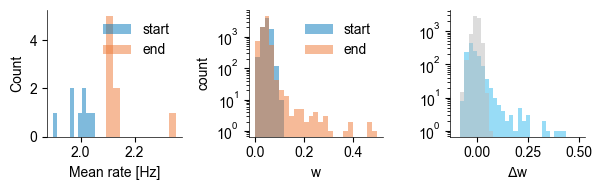

In [27]:
plt.style.use(['nature_d'])
fig, axs = plt.subplot_mosaic([["Rates", "All", "Diff"]], sharey=False)

panels = [
    ("All", "all"),
    ("Diff", "stim"),
    ("Diff", "!stim")
]

axs["Rates"].hist(all_rates['all']['s'], alpha=0.5, label='start', color=DARK_BLUE)
axs["Rates"].hist(all_rates['all']['e'], alpha=0.5, label='end',   color=ORANGE)
axs["Rates"].set_xlabel("Mean rate [Hz]")
axs["Rates"].set_ylabel("Count")
axs["Rates"].legend()

# ws
for title, key in panels:
    ax = axs[title]
    start = all_weights[key]['s']
    end   = all_weights[key]['e']

    if title != "All":
        bins = np.arange(-0.1001, 0.5001, 0.02)
        color = GRAY if key == '!stim' else LIGHT_BLUE
        label = "rest" if key == '!stim' else "stimulated"
        ax.hist(end - start, bins=bins, alpha=0.5, color=color, label=label)
    else:
        bins = np.arange(0, 0.5001, 0.02)
        ax.hist(start, bins=bins, alpha=0.5, label='start', color=DARK_BLUE)
        ax.hist(end,   bins=bins, alpha=0.5, label='end',   color=ORANGE)

    ax.set_yscale('log')

axs["All"].set_ylabel("count")
axs["All"].legend()
axs["All"].set_xlabel('w')

# axs["Diff"].legend()
axs["Diff"].set_xlabel(r'$\Delta$w')

w, h = fig.get_size_inches()
fig.set_size_inches(w, 2) 

fig.tight_layout()

if SAVE:
    fig.savefig("fig_2_weights.pdf", dpi=300)

plt.show()


In [28]:
weight_distributions = {
    'dd_s': np.array([]), 'dd_e': np.array([]),
    'du_s': np.array([]), 'du_e': np.array([]),
    'dn_s': np.array([]), 'dn_e': np.array([]),  # D to non-motor
    'ud_s': np.array([]), 'ud_e': np.array([]),
    'uu_s': np.array([]), 'uu_e': np.array([]),
    'un_s': np.array([]), 'un_e': np.array([])   # U to non-motor
}

# Calculate the weight distributions of each stimulated neuron to the motor areas
for i in range(N_TRIALS):
    n_stim = len(data[i]['ids']['stimulation_ids'])
    d_stim_ids = data[i]['ids']['stimulation_ids'][:n_stim//2]
    u_stim_ids = data[i]['ids']['stimulation_ids'][n_stim//2:]
    
    # Get all motor IDs (both D and U)
    all_motor_ids = np.concatenate([data[i]['ids']['motor_ids_D'], 
                                     data[i]['ids']['motor_ids_U']])
    
    # Define configurations: (stim_ids, motor_ids, prefix)
    configs = [
        (d_stim_ids, data[i]['ids']['motor_ids_D'], 'dd'),
        (d_stim_ids, data[i]['ids']['motor_ids_U'], 'du'),
        (d_stim_ids, None, 'dn'),  # D to non-motor (will handle separately)
        (u_stim_ids, data[i]['ids']['motor_ids_D'], 'ud'),
        (u_stim_ids, data[i]['ids']['motor_ids_U'], 'uu'),
        (u_stim_ids, None, 'un')   # U to non-motor (will handle separately)
    ]
    
    for stim_ids, motor_ids, prefix in configs:
        if motor_ids is None:
            # Non-motor: connections from stim_ids to neurons NOT in motor areas
            mask = (np.isin(data[i]['pre'], stim_ids) & 
                    ~np.isin(data[i]['post'], all_motor_ids))
        else:
            mask = (np.isin(data[i]['pre'], stim_ids) & 
                    np.isin(data[i]['post'], motor_ids))
        
        weight_distributions[f'{prefix}_s'] = np.hstack((weight_distributions[f'{prefix}_s'], 
                                                         data[i]['ws']['s'][mask]))
        weight_distributions[f'{prefix}_e'] = np.hstack((weight_distributions[f'{prefix}_e'], 
                                                         data[i]['ws']['e'][mask]))

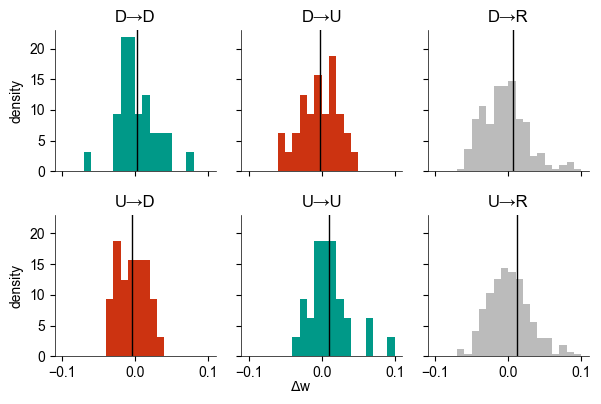

In [29]:
plt.style.use(['nature_d'])
fig, axs = plt.subplot_mosaic([['dd', 'du', 'dn'],
                                ['ud', 'uu', 'un']], 
                               sharex=True, sharey=True)

# Define the combinations
combinations = [
    ('dd', 'D→D'),
    ('du', 'D→U'),
    ('dn', 'D→R'),
    ('ud', 'U→D'),
    ('uu', 'U→U'),
    ('un', 'U→R')
]

bins = np.arange(-0.1001, 0.1001, 0.01)
for prefix, label in combinations:
    weight_change = weight_distributions[f'{prefix}_e'] - weight_distributions[f'{prefix}_s']
    
    # Color coding: green for same-region, red for cross-region, gray for non-motor
    if prefix in ['dd', 'uu']:
        color = GREEN
    elif prefix in ['dn', 'un']:
        color = GRAY
    else:
        color = RED
    
    axs[prefix].hist(weight_change, bins=bins, color=color, density=True)
    axs[prefix].axvline(np.mean(weight_change), color='black')
    axs[prefix].set_title(f'{label}')

axs['dd'].set_ylabel('density')
axs['ud'].set_ylabel('density')

# Add single centered x-label using plt.text
fig.text(0.5, 0.02, r'$\Delta$w', 
         ha='center', va='center')

w, h = fig.get_size_inches()
fig.set_size_inches(w, 4) 

plt.tight_layout()
if SAVE:
    fig.savefig("fig_3_weights.pdf", dpi=300)
plt.show()